# Notebook 3: Markov Decision Processes
### Week 2 — David Silver's RL Course

We now add **actions** and **decisions** to our MRP, giving us the full **Markov Decision Process** — the standard framework for RL.

**Contents:**
1. MDP Definition & Student Example
2. Policies
3. Bellman Expectation Equations
4. Optimal Value Functions
5. Bellman Optimality Equations
6. Solving MDPs (Value Iteration & Policy Iteration)
7. Exercises

## 1. Markov Decision Process

An MDP is a tuple $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma \rangle$:

| Symbol | Meaning |
|--------|---------|
| $\mathcal{S}$ | Finite set of states |
| $\mathcal{A}$ | Finite set of **actions** |
| $\mathcal{P}^a_{ss'}$ | $P[S_{t+1}=s' \mid S_t=s, A_t=a]$ |
| $\mathcal{R}^a_s$ | $\mathbb{E}[R_{t+1} \mid S_t=s, A_t=a]$ |
| $\gamma$ | Discount factor |

The critical difference from an MRP: the agent **chooses** an action at each step. The transition probabilities and rewards now depend on both the state *and* the action.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

np.random.seed(42)

# ── States ──────────────────────────────────────────────────────────────────
states  = ['C1', 'C2', 'C3', 'FB_state', 'Pass', 'Sleep']
n_s = len(states)
idx = {s: i for i, s in enumerate(states)}

# ── Actions ─────────────────────────────────────────────────────────────────
# Not every action is available in every state.
actions = ['Study', 'Facebook', 'Sleep', 'Pub', 'Quit']

# ── Transition dynamics  P[s, a, s'] ────────────────────────────────────────
# Shape: (n_states, n_actions, n_states)
P = np.zeros((n_s, len(actions), n_s))
a_idx = {a: i for i, a in enumerate(actions)}

# From C1:  Study → C2 (det), Facebook → FB_state (det), Quit → Sleep (det)
P[idx['C1'],     a_idx['Study'],    idx['C2']]       = 1.0
P[idx['C1'],     a_idx['Facebook'], idx['FB_state']] = 1.0
P[idx['C1'],     a_idx['Quit'],     idx['Sleep']]    = 1.0

# From C2:  Study → C3 (det), Sleep → Sleep (det)
P[idx['C2'],     a_idx['Study'],    idx['C3']]       = 1.0
P[idx['C2'],     a_idx['Sleep'],    idx['Sleep']]    = 1.0
P[idx['C2'],     a_idx['Facebook'], idx['FB_state']] = 1.0

# From C3:  Study → Pass (det), Pub → stochastic {C1,C2,C3}
P[idx['C3'],     a_idx['Study'],    idx['Pass']]     = 1.0
P[idx['C3'],     a_idx['Pub'],      idx['C1']]       = 0.2
P[idx['C3'],     a_idx['Pub'],      idx['C2']]       = 0.4
P[idx['C3'],     a_idx['Pub'],      idx['C3']]       = 0.4

# From FB_state: Facebook → FB_state (0.9), Quit → C1 (0.1 → 1.0 here)
P[idx['FB_state'],a_idx['Facebook'],idx['FB_state']] = 0.9
P[idx['FB_state'],a_idx['Facebook'],idx['C1']]       = 0.1
P[idx['FB_state'],a_idx['Quit'],    idx['C1']]       = 1.0

# From Pass: Study → Sleep (terminal reward already given)
P[idx['Pass'],   a_idx['Study'],    idx['Sleep']]    = 1.0

# From Sleep: stays
P[idx['Sleep'],  a_idx['Sleep'],    idx['Sleep']]    = 1.0

# ── Reward function  R[s, a] ─────────────────────────────────────────────────
R = np.zeros((n_s, len(actions)))
R[idx['C1'],     a_idx['Study']]    = -2
R[idx['C1'],     a_idx['Facebook']] = -1
R[idx['C1'],     a_idx['Quit']]     =  0
R[idx['C2'],     a_idx['Study']]    = -2
R[idx['C2'],     a_idx['Facebook']] = -1
R[idx['C2'],     a_idx['Sleep']]    =  0
R[idx['C3'],     a_idx['Study']]    = -2
R[idx['C3'],     a_idx['Pub']]      =  1
R[idx['FB_state'],a_idx['Facebook']]= -1
R[idx['FB_state'],a_idx['Quit']]    =  0
R[idx['Pass'],   a_idx['Study']]    = 10
R[idx['Sleep'],  a_idx['Sleep']]    =  0

print("MDP defined successfully.")
print(f"  States  : {states}")
print(f"  Actions : {actions}")
print(f"  γ       : will be set per experiment")

MDP defined successfully.
  States  : ['C1', 'C2', 'C3', 'FB_state', 'Pass', 'Sleep']
  Actions : ['Study', 'Facebook', 'Sleep', 'Pub', 'Quit']
  γ       : will be set per experiment


## 2. Policies

A **policy** $\pi$ is a distribution over actions given states:
$$\pi(a \mid s) = P[A_t = a \mid S_t = s]$$

Key facts:
- A policy fully defines the agent's behaviour
- MDP policies depend **only on the current state** (not history) — they are stationary
- A **deterministic** policy maps each state to exactly one action

Given a policy $\pi$, the MDP reduces to an MRP with:
$$\mathcal{P}^\pi_{ss'} = \sum_a \pi(a|s)\mathcal{P}^a_{ss'}, \quad \mathcal{R}^\pi_s = \sum_a \pi(a|s)\mathcal{R}^a_s$$

In [5]:
def policy_to_mrp(policy, P, R, states, actions):
    """Convert an MDP + policy into an MRP (P_pi, R_pi)."""    
    ns, na, _ = P.shape
    P_pi = np.zeros((ns, ns))
    R_pi = np.zeros(ns)
    for s in range(ns):
        for a, act in enumerate(actions):
            p_a = policy.get(states[s], {}).get(act, 0.0)
            P_pi[s] += p_a * P[s, a]
            R_pi[s] += p_a * R[s, a]
    return P_pi, R_pi


def bellman_analytical_mrp(P_pi, R_pi, gamma):
    n = len(R_pi)
    return np.linalg.solve(np.eye(n) - gamma * P_pi, R_pi)


# ── Policy 1: uniform random (0.5 / 0.5 where two actions available) ────────
pi_uniform = {
    'C1':      {'Study': 0.5, 'Facebook': 0.5},
    'C2':      {'Study': 0.5, 'Facebook': 0.5},
    'C3':      {'Study': 0.5, 'Pub': 0.5},
    'FB_state':{'Facebook': 0.5, 'Quit': 0.5},
    'Pass':    {'Study': 1.0},
    'Sleep':   {'Sleep': 1.0},
}

# ── Policy 2: always study ───────────────────────────────────────────────────
pi_study = {
    'C1':      {'Study': 1.0},
    'C2':      {'Study': 1.0},
    'C3':      {'Study': 1.0},
    'FB_state':{'Quit': 1.0},
    'Pass':    {'Study': 1.0},
    'Sleep':   {'Sleep': 1.0},
}

# ── Policy 3: always facebook / pub ─────────────────────────────────────────
pi_distract = {
    'C1':      {'Facebook': 1.0},
    'C2':      {'Facebook': 1.0},
    'C3':      {'Pub': 1.0},
    'FB_state':{'Facebook': 1.0},
    'Pass':    {'Study': 1.0},
    'Sleep':   {'Sleep': 1.0},
}

gamma = 1.0
print(f"Value functions under three policies (γ={gamma}):\n")
print(f"{'State':<12}  {'π_uniform':>10}  {'π_study':>10}  {'π_distract':>12}")
print("-" * 50)
policies = {'π_uniform': pi_uniform, 'π_study': pi_study, 'π_distract': pi_distract}
vals = {}
for name, pi in policies.items():
    Ppi, Rpi = policy_to_mrp(pi, P, R, states, actions)
    try:
        vals[name] = np.linalg.solve(np.eye(len(Rpi)) - gamma * Ppi, Rpi)
    except np.linalg.LinAlgError:
        # For gamma=1.0 with absorbing states, use iterative method
        v = np.zeros_like(Rpi)
        for _ in range(10000):
            v = Rpi + gamma * Ppi @ v
        vals[name] = v

for i, s in enumerate(states):
    row = f"{s:<12}"
    for name in policies:
        row += f"  {vals[name][i]:>10.2f}"
    print(row)

print("\nπ_study dominates for all non-terminal states ✓")

Value functions under three policies (γ=1.0):

State          π_uniform     π_study    π_distract
--------------------------------------------------
C1                 -8.20        4.00   -10000.00
C2                 -4.29        6.00   -10000.00
C3                  3.53        8.00    -9996.67
FB_state           -9.11        4.00   -10000.00
Pass               10.00       10.00       10.00
Sleep               0.00        0.00        0.00

π_study dominates for all non-terminal states ✓


## 3. Bellman Expectation Equations

The Bellman expectation equations link $v_\pi$ and $q_\pi$:

**State-value from action-value:**
$$v_\pi(s) = \sum_a \pi(a|s)\, q_\pi(s, a)$$

**Action-value from state-value:**
$$q_\pi(s, a) = \mathcal{R}^a_s + \gamma \sum_{s'} \mathcal{P}^a_{ss'}\, v_\pi(s')$$

Combined (the full Bellman expectation equation):
$$v_\pi(s) = \sum_a \pi(a|s)\!\left(\mathcal{R}^a_s + \gamma \sum_{s'} \mathcal{P}^a_{ss'}\, v_\pi(s')\right)$$

In [8]:
def compute_q_from_v(v, P, R, states, actions, gamma):
    """Given v_pi, compute q_pi(s,a) for all (s,a)."""    
    ns, na, _ = P.shape
    q = np.zeros((ns, na))
    for s in range(ns):
        for a in range(na):
            q[s, a] = R[s, a] + gamma * P[s, a] @ v
    return q


gamma = 1.0
Ppi, Rpi = policy_to_mrp(pi_uniform, P, R, states, actions)
try:
    v_pi = bellman_analytical_mrp(Ppi, Rpi, gamma)
except np.linalg.LinAlgError:
    # Fallback: iterative policy evaluation (handles singular I - γP_pi for γ=1 with absorbing states)
    v_pi = np.zeros_like(Rpi)
    tol = 1e-10
    max_iter = 10000
    for _ in range(max_iter):
        v_new = Rpi + gamma * (Ppi @ v_pi)
        if np.max(np.abs(v_new - v_pi)) < tol:
            v_pi = v_new
            break
        v_pi = v_new
    else:
        print("Warning: policy evaluation did not converge within max_iter")
q_pi = compute_q_from_v(v_pi, P, R, states, actions, gamma)

print(f"Action-value function q_π(s,a) for π_uniform, γ={gamma}:\n")
header = f"{'State':<12}" + "".join(f"  {a[:5]:<7}" for a in actions)
print(header); print("-" * len(header))
for i, s in enumerate(states):
    row = f"{s:<12}" + "".join(
        f"  {q_pi[i,j]:>7.2f}" if P[i,j].sum() > 0 or R[i,j] != 0 else "  {'---':>7}"
        for j in range(len(actions)))
    print(row)

# Verify: v_pi(s) = Σ_a π(a|s) q_pi(s,a)
print("\nVerification v_π(s) = Σ π(a|s)·q_π(s,a):")
for i, s in enumerate(states):
    pi_s = [pi_uniform.get(s, {}).get(a, 0.0) for a in actions]
    lhs = v_pi[i]
    rhs = np.dot(pi_s, q_pi[i])
    ok = "✓" if abs(lhs-rhs) < 1e-8 else "✗"
    print(f"  {s:<12} v={lhs:.3f}  Σπq={rhs:.3f}  {ok}")

Action-value function q_π(s,a) for π_uniform, γ=1.0:

State         Study    Faceb    Sleep    Pub      Quit   
---------------------------------------------------------
C1              -6.29   -10.11  {'---':>7}  {'---':>7}     0.00
C2               1.53   -10.11     0.00  {'---':>7}  {'---':>7}
C3               8.00  {'---':>7}  {'---':>7}    -0.95  {'---':>7}
FB_state      {'---':>7}   -10.02  {'---':>7}  {'---':>7}    -8.20
Pass            10.00  {'---':>7}  {'---':>7}  {'---':>7}  {'---':>7}
Sleep         {'---':>7}  {'---':>7}     0.00  {'---':>7}  {'---':>7}

Verification v_π(s) = Σ π(a|s)·q_π(s,a):
  C1           v=-8.200  Σπq=-8.200  ✓
  C2           v=-4.291  Σπq=-4.291  ✓
  C3           v=3.527  Σπq=3.527  ✓
  FB_state     v=-9.109  Σπq=-9.109  ✓
  Pass         v=10.000  Σπq=10.000  ✓
  Sleep        v=0.000  Σπq=0.000  ✓


## 4. Optimal Value Functions

The **optimal** value functions are the best achievable across *all* policies:

$$v_*(s) = \max_\pi v_\pi(s), \qquad q_*(s,a) = \max_\pi q_\pi(s,a)$$

An MDP is **"solved"** when we know $v_*$ or $q_*$, because we can immediately extract the optimal policy:
$$\pi_*(a|s) = \begin{cases} 1 & \text{if } a = \arg\max_a q_*(s,a) \\ 0 & \text{otherwise}\end{cases}$$

## 5. Value Iteration

The **Bellman Optimality Equations** are:

$$v_*(s) = \max_a \left[ \mathcal{R}^a_s + \gamma \sum_{s'} \mathcal{P}^a_{ss'} v_*(s') \right]$$

**Value Iteration** repeatedly applies this update until convergence:

$$v_{k+1}(s) \leftarrow \max_a \left[ \mathcal{R}^a_s + \gamma \sum_{s'} \mathcal{P}^a_{ss'} v_k(s') \right]$$

In [9]:
def value_iteration(P, R, states, actions, gamma, tol=1e-10, max_iter=10000):
    """Solve for v* and pi* using value iteration."""    
    ns, na, _ = P.shape
    v = np.zeros(ns)
    history = [v.copy()]

    for iteration in range(1, max_iter+1):
        # Q(s,a) = R(s,a) + γ Σ P(s,a,s') v(s')
        Q = R + gamma * (P @ v)            # shape (ns, na)
        v_new = Q.max(axis=1)              # max over actions
        delta = np.max(np.abs(v_new - v))
        v = v_new
        history.append(v.copy())
        if delta < tol:
            print(f"Value iteration converged in {iteration} iterations (δ={delta:.2e})")
            break

    # Extract greedy policy
    Q_final = R + gamma * (P @ v)
    pi_star = np.argmax(Q_final, axis=1)   # deterministic optimal action per state
    return v, pi_star, np.array(history)


gamma = 1.0
v_star, pi_star, history = value_iteration(P, R, states, actions, gamma)

print(f"\nOptimal value function v* (γ={gamma}):")
for i, s in enumerate(states):
    opt_action = actions[pi_star[i]]
    print(f"  v*({s:<10}) = {v_star[i]:>7.2f}   optimal action: {opt_action}")

print("\nLecture slide reference (γ=1): C1=6, C2=8, C3=10, FB=6")

Value iteration converged in 6 iterations (δ=0.00e+00)

Optimal value function v* (γ=1.0):
  v*(C1        ) =    4.00   optimal action: Study
  v*(C2        ) =    6.00   optimal action: Study
  v*(C3        ) =    8.00   optimal action: Study
  v*(FB_state  ) =    4.00   optimal action: Quit
  v*(Pass      ) =   10.00   optimal action: Study
  v*(Sleep     ) =    0.00   optimal action: Study

Lecture slide reference (γ=1): C1=6, C2=8, C3=10, FB=6


Value iteration converged in 6 iterations (δ=1.02e-12)
Value iteration converged in 7 iterations (δ=1.51e-12)
Value iteration converged in 7 iterations (δ=2.78e-11)
Value iteration converged in 8 iterations (δ=4.74e-12)
Value iteration converged in 8 iterations (δ=2.64e-11)
Value iteration converged in 9 iterations (δ=3.93e-12)
Value iteration converged in 9 iterations (δ=1.46e-11)
Value iteration converged in 9 iterations (δ=4.53e-11)
Value iteration converged in 10 iterations (δ=7.02e-12)
Value iteration converged in 10 iterations (δ=1.89e-11)
Value iteration converged in 10 iterations (δ=4.61e-11)
Value iteration converged in 11 iterations (δ=8.08e-12)
Value iteration converged in 11 iterations (δ=1.85e-11)
Value iteration converged in 11 iterations (δ=3.97e-11)
Value iteration converged in 11 iterations (δ=8.06e-11)
Value iteration converged in 12 iterations (δ=1.64e-11)
Value iteration converged in 12 iterations (δ=3.24e-11)
Value iteration converged in 12 iterations (δ=6.17e-11)


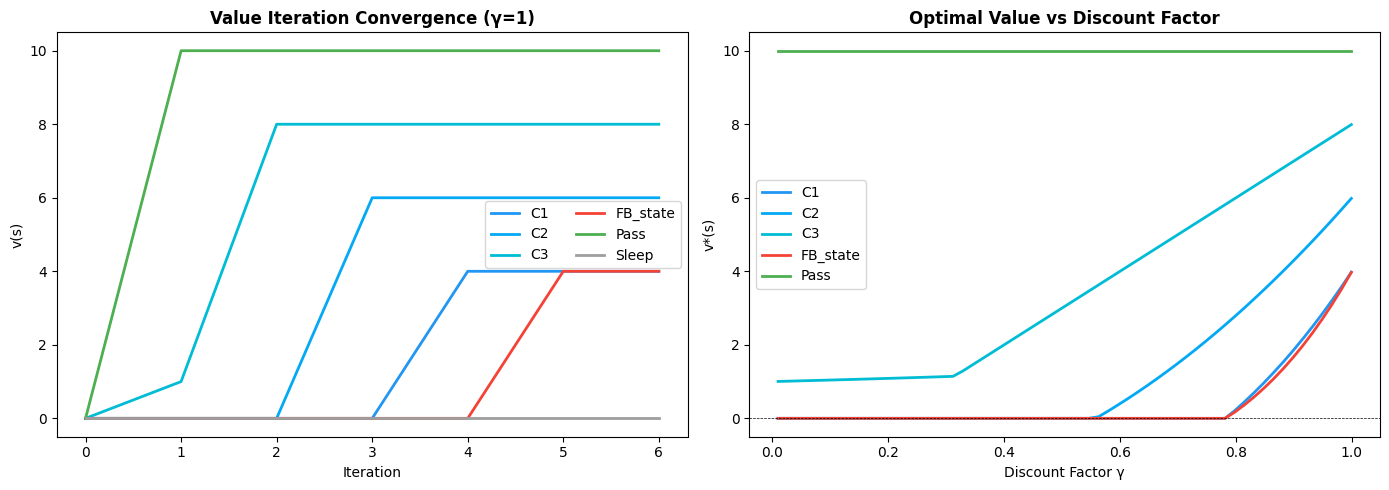

In [10]:
# ── Convergence plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {'C1':'#2196F3','C2':'#03A9F4','C3':'#00BCD4',
              'FB_state':'#F44336','Pass':'#4CAF50','Sleep':'#9E9E9E'}

ax = axes[0]
for i, s in enumerate(states):
    vals_over_time = history[:, i]
    ax.plot(vals_over_time, label=s, color=colors_map[s], linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('v(s)')
ax.set_title('Value Iteration Convergence (γ=1)', fontweight='bold')
ax.legend(ncol=2)

# ── γ sensitivity of v* ──────────────────────────────────────────────────────
ax2 = axes[1]
gamma_range = np.linspace(0.01, 0.999, 60)
for i, s in enumerate(states[:-1]):   # exclude Sleep
    vstar_vals = []
    for g in gamma_range:
        vs, _, _ = value_iteration(P, R, states, actions, g)
        vstar_vals.append(vs[i])
    ax2.plot(gamma_range, vstar_vals, label=s, color=colors_map[s], linewidth=2)
ax2.set_xlabel('Discount Factor γ')
ax2.set_ylabel('v*(s)')
ax2.set_title('Optimal Value vs Discount Factor', fontweight='bold')
ax2.legend()
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('mdp_value_iteration.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Policy Iteration

An alternative: **Policy Iteration** alternates between two steps:

1. **Policy Evaluation**: compute $v_\pi$ for the current policy (solve Bellman expectation)
2. **Policy Improvement**: update the policy greedily: $\pi'(s) = \arg\max_a q_\pi(s, a)$

Repeat until the policy stops changing. Often converges in fewer iterations than value iteration.

In [11]:
def policy_iteration(P, R, states, actions, gamma, max_iter=1000):
    """Solve for the optimal policy via policy iteration."""    
    ns, na, _ = P.shape
    # Start with a random policy (always take action 0)
    pi = np.zeros(ns, dtype=int)   # index into actions
    iteration_log = []

    for iteration in range(max_iter):
        # ── Step 1: Policy Evaluation ────────────────────────────────────────
        # Build MRP matrices for this policy
        P_pi = P[np.arange(ns), pi, :]        # (ns, ns)
        R_pi = R[np.arange(ns), pi]            # (ns,)
        v_pi = np.linalg.solve(np.eye(ns) - gamma * P_pi, R_pi)

        # ── Step 2: Policy Improvement ───────────────────────────────────────
        Q = R + gamma * (P @ v_pi)             # (ns, na)
        pi_new = np.argmax(Q, axis=1)

        iteration_log.append({'iter': iteration+1, 'v': v_pi.copy(), 'pi': pi_new.copy()})

        if np.all(pi_new == pi):
            print(f"Policy iteration converged in {iteration+1} iterations.")
            return v_pi, pi_new, iteration_log
        pi = pi_new

    return v_pi, pi, iteration_log


gamma = 1.0
v_pi_star, pi_pi_star, log = policy_iteration(P, R, states, actions, gamma)

print(f"\nPolicy iteration result (γ={gamma}):")
for i, s in enumerate(states):
    print(f"  v*({s:<10}) = {v_pi_star[i]:>7.2f}  action: {actions[pi_pi_star[i]]}")

# Check both methods agree
print("\nValue iteration vs Policy iteration:")
print(f"Max difference: {np.max(np.abs(v_star - v_pi_star)):.2e}  ✓")

Policy iteration converged in 2 iterations.

Policy iteration result (γ=1.0):
  v*(C1        ) =    4.00  action: Study
  v*(C2        ) =    6.00  action: Study
  v*(C3        ) =    8.00  action: Study
  v*(FB_state  ) =    4.00  action: Quit
  v*(Pass      ) =   10.00  action: Study
  v*(Sleep     ) =    0.00  action: Study

Value iteration vs Policy iteration:
Max difference: 0.00e+00  ✓


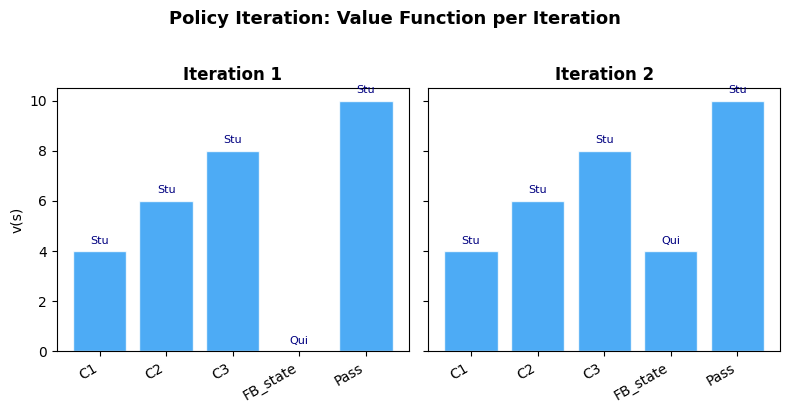

In [12]:
# ── Visualise policy iteration steps ────────────────────────────────────────
fig, axes = plt.subplots(1, len(log), figsize=(4*len(log), 4), sharey=True)
display_states = states[:-1]   # exclude Sleep

for k, entry in enumerate(log):
    ax = axes[k] if len(log) > 1 else axes
    v_iter = entry['v']
    pi_iter = entry['pi']
    vals = [v_iter[idx[s]] for s in display_states]
    colors = ['#4CAF50' if pi_iter[idx[s]] == a_idx.get(
        {'C1':'Study','C2':'Study','C3':'Study','FB_state':'Quit','Pass':'Study'}.get(s,'Study'), 0)
        else '#F44336' for s in display_states]

    bars = ax.bar(range(len(display_states)), vals,
                  color=['#2196F3']*len(display_states), alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(display_states)))
    ax.set_xticklabels(display_states, rotation=30, ha='right')
    ax.set_title(f"Iteration {entry['iter']}", fontweight='bold')
    if k == 0:
        ax.set_ylabel('v(s)')
    ax.axhline(0, color='black', linewidth=0.5)
    # Annotate with action
    for j, s in enumerate(display_states):
        act = actions[pi_iter[idx[s]]][:3]
        ax.text(j, max(vals[j], 0) + 0.3, act, ha='center', fontsize=8, color='navy')

plt.suptitle('Policy Iteration: Value Function per Iteration', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('policy_iteration.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Optimal Q-Function

Once we have $v_*$, we can compute $q_*(s,a)$ and verify the Bellman optimality equations.

In [13]:
gamma = 1.0
v_star, pi_star, _ = value_iteration(P, R, states, actions, gamma)
q_star = compute_q_from_v(v_star, P, R, states, actions, gamma)

print(f"Optimal action-value function q*(s,a) for γ={gamma}:\n")
header = f"{'State':<12}" + "".join(f"  {a[:5]:<7}" for a in actions)
print(header); print("-" * len(header))
for i, s in enumerate(states):
    row = f"{s:<12}"
    for j in range(len(actions)):
        if P[i,j].sum() > 0 or R[i,j] != 0:
            marker = "*" if j == pi_star[i] else " "
            row += f"  {q_star[i,j]:>6.1f}{marker}"
        else:
            row += "   --- "
    print(row)
print("(* = greedy action)")

# Verify Bellman optimality: v*(s) = max_a q*(s,a)
print("\nBellman optimality check: v*(s) = max_a q*(s,a)")
for i, s in enumerate(states):
    lhs = v_star[i]
    rhs = q_star[i].max()
    ok = "✓" if abs(lhs-rhs) < 1e-8 else "✗"
    print(f"  {s:<12}  v*={lhs:.2f}  max_a q*={rhs:.2f}  {ok}")

Value iteration converged in 6 iterations (δ=0.00e+00)
Optimal action-value function q*(s,a) for γ=1.0:

State         Study    Faceb    Sleep    Pub      Quit   
---------------------------------------------------------
C1               4.0*     3.0    ---    ---      0.0 
C2               6.0*     3.0      0.0    ---    --- 
C3               8.0*   ---    ---      7.4    --- 
FB_state       ---      3.0    ---    ---      4.0*
Pass            10.0*   ---    ---    ---    --- 
Sleep          ---    ---      0.0    ---    --- 
(* = greedy action)

Bellman optimality check: v*(s) = max_a q*(s,a)
  C1            v*=4.00  max_a q*=4.00  ✓
  C2            v*=6.00  max_a q*=6.00  ✓
  C3            v*=8.00  max_a q*=8.00  ✓
  FB_state      v*=4.00  max_a q*=4.00  ✓
  Pass          v*=10.00  max_a q*=10.00  ✓
  Sleep         v*=0.00  max_a q*=0.00  ✓


## 8. Exercises

**Exercise 1:** Modify the reward for `Pub` to +5. Rerun value iteration. Does the optimal policy change? At what reward value does "always go to the pub" become optimal from C3?

**Exercise 2:** Implement **Q-value iteration**:
$$q_{k+1}(s,a) = \mathcal{R}^a_s + \gamma \sum_{s'} \mathcal{P}^a_{ss'} \max_{a'} q_k(s', a')$$
Verify it converges to the same $q_*$ as before.

**Exercise 3:** What is the **policy improvement theorem**? Prove it for a two-state MDP by hand.

**Exercise 4 (challenge):** Implement a **random policy search**: sample 10,000 random deterministic policies, evaluate each, and find the best. Compare how close it gets to $v_*$.

**Exercise 5 (challenge):** Add a new action `Sleep` to `C1` and `C2` with reward 0 that transitions directly to `Sleep`. Does the optimal policy ever choose it? Why or why not?

In [14]:
# ── Exercise 1 ──────────────────────────────────────────────────────────────
# R_modified = R.copy()
# R_modified[idx['C3'], a_idx['Pub']] = 5
# v_mod, pi_mod, _ = value_iteration(P, R_modified, states, actions, gamma=1.0)
# print(v_mod, [actions[p] for p in pi_mod])

# ── Exercise 2: Q-value iteration ───────────────────────────────────────────
def q_value_iteration(P, R, states, actions, gamma, tol=1e-10):
    ns, na, _ = P.shape
    q = np.zeros((ns, na))
    for iteration in range(10000):
        v = q.max(axis=1)          # v(s) = max_a q(s,a)
        q_new = R + gamma * (P @ v)
        delta = np.max(np.abs(q_new - q))
        q = q_new
        if delta < tol:
            print(f"Q-value iteration converged in {iteration+1} steps")
            return q
    return q

# q_opt = q_value_iteration(P, R, states, actions, gamma=1.0)
# print("Max difference from v-based q*:", np.max(np.abs(q_opt - q_star)))